# Numpy Polynomial Fitting Redux

![polyfit](../assets/images/numy-ploy-fit-redux-banner.png)

It recently came to my attention that my old post on [numpy polynomial fitting](https://eitanlees.github.io/numpy-poly-fit/) needed to be updated. There is a much more natural way to do this, and the [numpy.polynomial](https://numpy.org/doc/stable/reference/routines.polynomials-package.html#module-numpy.polynomial) submodule has been the recommened approach since Numpy 1.4 (I don't know how I missed it before). 

I will cover a similar example to the previous post

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import numpy as np
import matplotlib.pyplot as plt

### Generating data

We will create some different mock data this time

In [ ]:
# The unknown function we are trying to fit
f = lambda x: (x-3)**3 + (x-5)**2 - x + 2

# Generating the sample points
x = np.linspace(0, 5, 30)

# Adding gaussian noise to x and f(x)
np.random.seed(123456)
data_x =   x  + np.random.normal(0, .1, len(x))
data_y = f(x) + np.random.normal(0, .5, len(x))

Let's assume that this is our starting point. We are given some data and we wish to fit a polynomial.

[<matplotlib.lines.Line2D>]

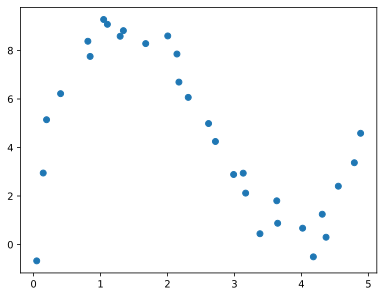

In [ ]:
plt.plot(data_x, data_y, 'o')

### Polynomial Fitting

For all of our polynomial needs we will use the `Polynomial` class from the `numpy.polynomial` submodule

[<matplotlib.lines.Line2D>]

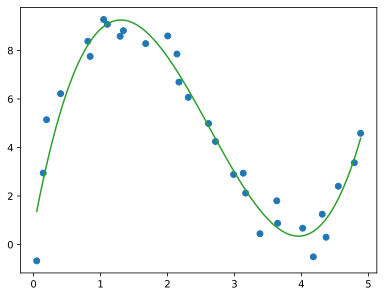

In [ ]:
from numpy.polynomial import Polynomial as P

p = P.fit(data_x, data_y, 3)
plt.plot(data_x, data_y, 'o')
plt.plot(*p.linspace(), 'C2')

The `Polynomial` convenience class cleans up a lot of the boiler plate from the previous post:

- We don't have to call two methods (`np.poly1d` and `np.polyfit`) to construct the polynomial. The single `Polynomial.fit` method returns the fitted polynomial directly.
- We don't have to worry about the order of the coefficients. All `np.polynomial` objects use the lowest to highest ordering for the coefficients.
- We don't have to manually create x points via `np.linspace` as the object has it's own linspace method. The domain is stored in the polynomial object which we will discuss shortly.

### A Quick Sidenote

Man! It's been a while! More than six years and I am back with post about a topic I've already covered. Weird huh?

Burying my "Welcome Back" post in an unassuming update to some numpy post I made eight years ago. Weird huh?

**Merriam-Webster**:
> In English, _[redux](https://www.merriam-webster.com/dictionary/redux)_ describes things that have been brought back—metaphorically, that is. 

(Look at that em dash! I wonder if AI is writing the dictionary now. A real [Ouroboros](https://en.wikipedia.org/wiki/Ouroboros)!)

In a way I find it fitting. I would like to post more. I would like a redux. I miss scientific computing!

### Onwards and Upwards

We can leverage this pattern to fit any sort of higher order polynomial

[<matplotlib.lines.Line2D>]

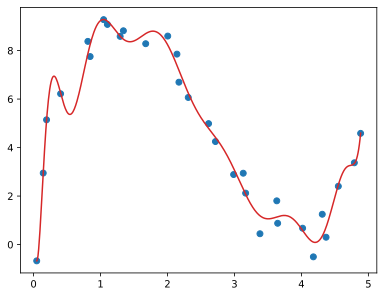

In [ ]:
p = P.fit(data_x, data_y, 15)
plt.plot(data_x, data_y, 'o')
plt.plot(*p.linspace(500), 'C3')

or put this logic into a loop

<matplotlib.legend.Legend>

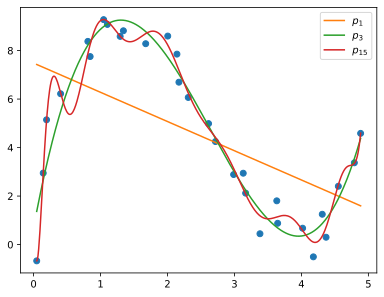

In [ ]:
plt.plot(data_x, data_y, 'o')
for i in [1, 3, 15]:
    p = P.fit(data_x, data_y, i)
    plt.plot(*p.linspace(500), label=f'$p_{{{i}}}$')
plt.legend()

That should cover all of your polynomial fitting needs.

### Going Deeper

We can inspect this polynomial object a little closer to get a better understanding of what is going on under the hood

In [ ]:
p = P.fit(data_x, data_y, 3)
p

Polynomial([  5.62442401, -11.99900987,  -2.75135202,  13.50409619], domain=[0.04691123, 4.88421077], window=[-1.,  1.], symbol='x')

EEK! That is a little more complicated than I expected. It looks like someone shoved a bunch of linear transforms into a more canoical polynomial form.

Instead of 

$$
p_n(x) = \sum_{i=0}^{n} c_i x^i
$$

we have something like 

$$
p_n(x) = \sum_{i=0}^{n} c_i (a_i + b_i x)^i
$$

It turns out this is exactly what is going on but lets see what other attributes it has first

In [ ]:
p.__dict__

{'coef': array([  5.62442401, -11.99900987,  -2.75135202,  13.50409619]),
 'domain': array([0.04691123, 4.88421077]),
 'window': array([-1.,  1.]),
 '_symbol': 'x'}

Here is what I have gleaned from the documentation

- `coef` are the coefficients
- `domain` is the x range of the data we are fitting
- `window` is the x range where the reference polynomial is well behaved
- `_symbol` I don't know, but I guess it is used for the display

From the documentation:

> When the fit is done, the domain is first mapped to the window by a linear transformation and the usual least squares fit is done using the mapped data points.

The concept of using a domain and window like this was new to me and I recommend reading [the full numpy tutorial](https://numpy.org/doc/stable/reference/routines.polynomials.classes.html#fitting) for a detailed walkthrough.


If you are only fitting and using the polynomial object then these details are hidden and all calculations are performed correctly behind the scenes. If you want to convert this mapped polynomial to a more familure form you can use the `convert()` method

In [ ]:
p.convert()

Polynomial([ 0.69185045, 14.7642186 , -7.52998383,  0.95443546], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

These coefficients can then be reported or shared with other methods that expect the canonical form

In [ ]:
p.convert().coef

array([ 0.69185045, 14.7642186 , -7.52998383,  0.95443546])

Now I can sleep at night knowing I have corrected my past mistakes of recommending `np.poly1d` and `np.polyfit` for numpy polynomial fitting. Checking PyPI it looks like [Numpy 1.4](https://pypi.org/project/numpy/1.4.0/) was released December 27, 2009, well before my post so I wonder how I missed it. 
Oh well, take care for now and I will see you next time `:)`